# User Story 2 : Prétraitement des données - Gestion des valeurs manquantes et aberrantes

## Identifier et traiter les valeurs manquantes

In [100]:
#load data(le jeu de données est déjà nettoyé ; pas de valeurs manquantes ni de doublons)
from utils1 import *


content = load_data()


#valeurs manquantes
print(content.isnull().sum())

#valeur doublons
print(content.duplicated().sum())



insulin = (content["Insulin"] == 0).sum()
total_rows = len(content)
print(f"insulin : {insulin} | {(insulin/total_rows)*100:.2f}%  ")


bmi = (content["BMI"] == 0).sum()
print(f"BMI : {bmi} | {(bmi/total_rows)*100:.2f}%  ")

Glucose  = (content["Glucose"] == 0).sum()
print(f"Glucose  : {Glucose} | {(Glucose/total_rows)*100:.2f}%  ")

BloodPressure  = (content["BloodPressure"] == 0).sum()
print(f"BloodPressure  : {BloodPressure} | {(BloodPressure/total_rows)*100:.2f}%  ")

SkinThickness  = (content["SkinThickness"] == 0).sum()
print(f"SkinThickness  : {SkinThickness} | {(SkinThickness/total_rows)*100:.2f}%  ")

Unnamed: 0                  0
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64
0
insulin : 374 | 48.70%  
BMI : 11 | 1.43%  
Glucose  : 5 | 0.65%  
BloodPressure  : 35 | 4.56%  
SkinThickness  : 227 | 29.56%  


In [101]:
for col in cols_with_zeros:
    content[col] = content[col].replace(0,np.nan)

imputer = KNNImputer(n_neighbors=5)

content[cols_with_zeros] = imputer.fit_transform(content[cols_with_zeros] )

content.head(30)

,Unnamed: 0,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0,6,148.0,72.0,35.0,209.0,33.60,0.627,50
1,1,1,85.0,66.0,29.0,73.0,26.60,0.351,31
2,2,8,183.0,64.0,29.4,383.2,23.30,0.672,32
3,3,1,89.0,66.0,23.0,94.0,28.10,0.167,21
4,4,0,137.0,40.0,35.0,168.0,43.10,2.288,33
5,5,5,116.0,74.0,16.6,87.4,25.60,0.201,30
6,6,3,78.0,50.0,32.0,88.0,31.00,0.248,26
7,7,10,115.0,77.6,29.0,133.4,35.30,0.134,29
8,8,2,197.0,70.0,45.0,543.0,30.50,0.158,53
9,9,8,125.0,96.0,41.2,199.8,34.86,0.232,54


## Détection des valeurs aberrantes (outliers)

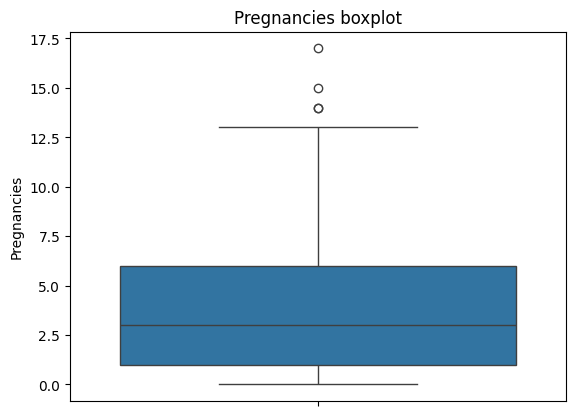

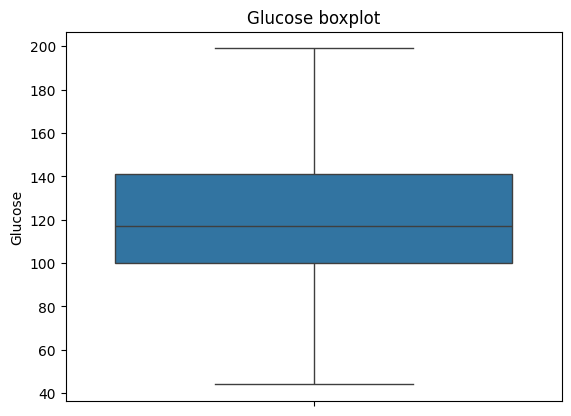

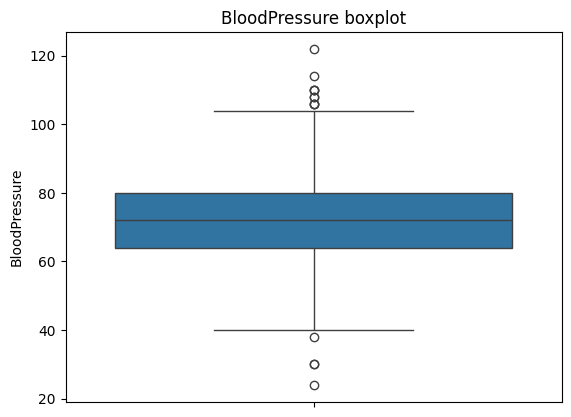

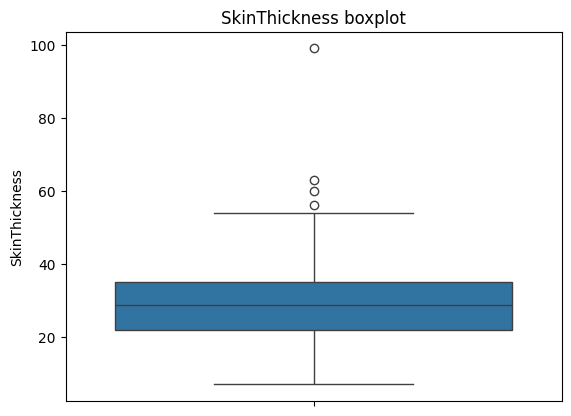

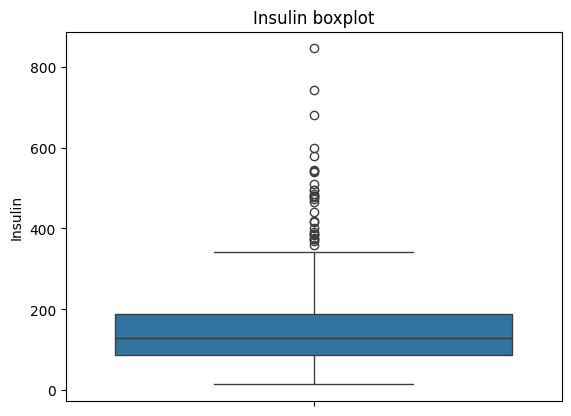

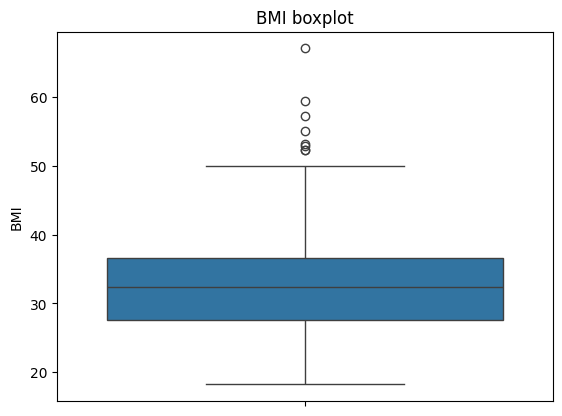

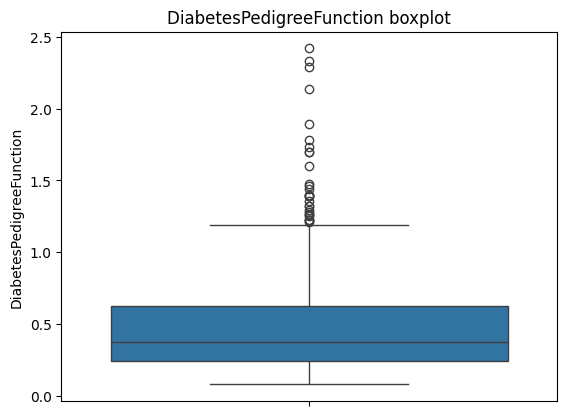

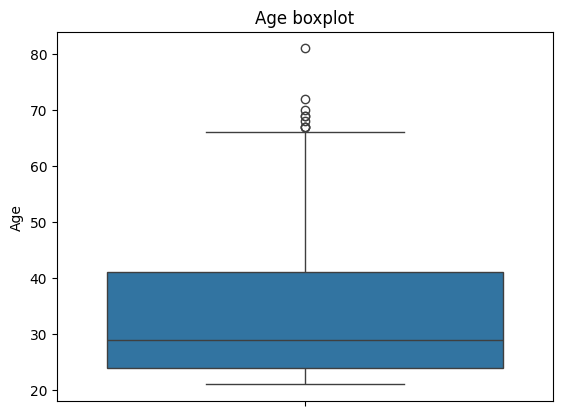

In [102]:
# boîte à moustaches des valeurs
cols = cols1()

for i,col in enumerate(cols,1):
    sbn.boxplot(y=content[col])
    mpt.title(f"{col} boxplot")
    mpt.show()




## Identification avec l’IQR

In [116]:


for col in cols:
    Q1 = content[col].quantile(0.25)   
    Q3 = content[col].quantile(0.75)
    IQR = Q3-Q1

    lower_bound = Q1-1.5*IQR
    upper_bound = Q3+1.5*IQR

    print(f"{col} -> Lower bound: {lower_bound}, Upper bound: {upper_bound}")
    outliers = content[(content[col]<lower_bound) | (content[col]>upper_bound)]


    print(outliers.count())


Pregnancies -> Lower bound: -6.5, Upper bound: 13.5
Unnamed: 0                  4
Pregnancies                 4
Glucose                     4
BloodPressure               4
SkinThickness               4
Insulin                     4
BMI                         4
DiabetesPedigreeFunction    4
Age                         4
dtype: int64
Glucose -> Lower bound: 37.875, Upper bound: 202.875
Unnamed: 0                  0
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64
BloodPressure -> Lower bound: 40.0, Upper bound: 104.0
Unnamed: 0                  14
Pregnancies                 14
Glucose                     14
BloodPressure               14
SkinThickness               14
Insulin                     14
BMI                         14
DiabetesPedigreeFunction    14
Age                       